<a href="https://colab.research.google.com/github/pollyyyu/biphasic_application_examples/blob/main/T_cell_no_IFFL_(minimal).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulation and plot for T-cell signalling pathway with no IFFL

In [1]:
!pip install tellurium

In [2]:
import tellurium as te

import numpy as np
from numpy.linalg import matrix_rank
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import LogNorm

from mpl_toolkits import mplot3d

import numpy as np
import io
import os
import pandas as pd

rgb_orange = (255, 95, 5)
rgb_blue = (0, 159, 212)
rgb_harvest = (252, 179, 22)

rgb_orange_norm = tuple(c / 255.0 for c in rgb_orange)
rgb_blue_norm = tuple(c / 255.0 for c in rgb_blue)
rgb_harvest_norm = tuple(c / 255.0 for c in rgb_harvest)


Text(0, 0.5, '$C_1^*$')

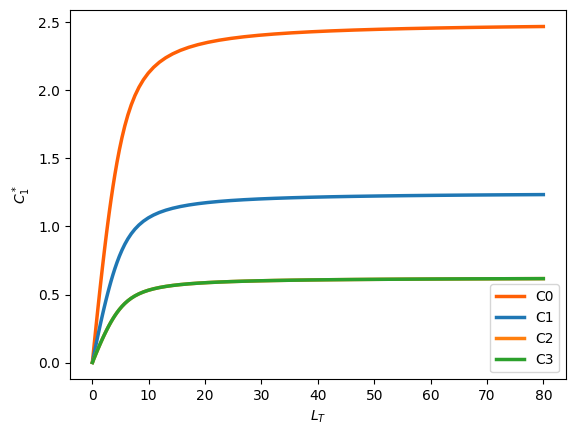

In [3]:
tfinal = 100;
n_timestep = 8000;
umin = 0.01
umax = 80
usteps = 100;

err_tol = 1e-6;

## KPR simulation
no_of_species = 6;
no_of_rxns = 8;
LT_array = np.logspace(np.log10(umin),np.log10(umax),usteps); ## Ltotal
Lfree_output_array = np.zeros(len(LT_array))
Rfree_output_array = np.zeros(len(LT_array))
C0_output_array = np.zeros(len(LT_array))
C1_output_array = np.zeros(len(LT_array))
C2_output_array = np.zeros(len(LT_array))
C3_output_array = np.zeros(len(LT_array))

ant_str_KPR =  """
  species L, R, C0, C1, C2, C3

  # ---------- McKeithan kinetic proofreading (N = 3) ----------
  bind:  L + R  -> C0;  kon*L*R;
  off0:  C0 -> L + R;   loff0*C0;
  ph0:   C0 -> C1;      kp0*C0;
  off1:  C1 -> L + R;   loff1*C1;
  ph1:   C1 -> C2;      kp1*C1;
  off2:  C2 -> L + R;   loff2*C2;
  ph2:   C2 -> C3;      kp2*C2;
  off3:  C3 -> L + R;   loff3*C3;

  # ---------- parameters ----------
  kon = 1;  loff0 = 1; loff1 = 1; loff2 = 1; loff3 = 1;
  kp0 = 1;  kp1 = 1;   kp2 = 1;

  R = 5;
"""



for ii in range(len(LT_array)):

  r = te.loada(ant_str_KPR)
  ## setting IC
  r.setValue('init(L)', LT_array[ii])
  r.conservedMoietyAnalysis = True

  ## run simulation and save final data
  results = r.simulate(0,tfinal,n_timestep)

  # #double check steady states
  species_list = results.colnames[1:]
  ss_values = results[-1, 1:]
  r.steadyState()
  r.getFloatingSpeciesConcentrations()
  r.getReactionRates()
  r.steadyStateSelections = species_list
  error = np.linalg.norm(r.getSteadyStateValues() - ss_values)/no_of_species
  if error > err_tol:
    print('Current L_T value = ', LT_array[ii])
    print('ss values read from results: ', ss_values)
    print('ss values from getSteadyStateValues: ', r.getSteadyStateValues())
    raise RuntimeError(f'Steady state not reached: error = {error:.3e} > tol = {err_tol:.1e}')

  # save steady state data
  Lfree_output_array[ii] = r.L
  Rfree_output_array[ii] = r.R
  C0_output_array[ii] = r.C0
  C1_output_array[ii] = r.C1
  C2_output_array[ii] = r.C2
  C3_output_array[ii] = r.C3

  # print(np.linalg.eigvals(r.getReducedJacobian()))


plt.plot(LT_array, C0_output_array, color=rgb_orange_norm,  linestyle='-', linewidth=2.5, label='C0')
plt.plot(LT_array, C1_output_array,   linestyle='-', linewidth=2.5, label='C1')
plt.plot(LT_array, C2_output_array,  linestyle='-', linewidth=2.5, label='C2')
plt.plot(LT_array, C3_output_array,   linestyle='-', linewidth=2.5, label='C3')
plt.legend()
plt.xlabel('$L_T$')
plt.ylabel('$C_1^*$')



In [4]:
u_array = C1_output_array

tfinal_relaxation = 500;

## signalling cascade simulation
no_of_phos_species = 4;
no_of_species = 2*no_of_phos_species;
no_of_rxns = 15;
X1p_output_array = np.zeros(len(u_array))
X2p_output_array = np.zeros(len(u_array))
X3p_output_array = np.zeros(len(u_array))
X4p_output_array = np.zeros(len(u_array))
fluxes_output_array = np.zeros((no_of_rxns, len(u_array))) ## to check for steady states
ss_error_array = np.zeros(len(u_array))

evals_output_array = np.zeros((no_of_phos_species,len(u_array)), dtype=complex)

ant_str =  """
  species C1, X1, X1p, X2, X2p, X3, X3p, X4, X4p

  # ---------- spontaneous (de)activation of the signaling proteins ----------
  a1: X1 -> X1p; alpha1*X1;    d1: X1p -> X1; beta1*X1p;
  a2: X2 -> X2p; alpha2*X2;    d2: X2p -> X2; beta2*X2p;
  a3: X3 -> X3p; alpha3*X3;    d3: X3p -> X3; beta3*X3p;
  a4: X4 -> X4p; alpha4*X4;    d4: X4p -> X4; beta4*X4p;

  # ---------- regulation (C1 -| X1 -> X2, X2 -| X1, X2 -| X3 -| X2, X2 -> X4 -> X2)
  eC1X1: $C1 + X1p  -> $C1 + X1;  eta1*C1*X1p  ;
  iX2X1: X2p + X1p -> X2p + X1;   c21*X2p*X1p ;
  aX1X2: X1p + X2  -> X1p + X2p;  k12*X1p*X2  ;
  iX2X3: X2p + X3p -> X2p + X3;   s23*X2p*X3p  ;
  iX3X2: X3p + X2p -> X3p + X2;   r32*X3p*X2p  ;
  aX2X4: X2p + X4  -> X2p + X4p;  t24*X2p*X4   ;
  aX4X2: X4p + X2  -> X4p + X2p;  k42*X4p*X2   ;

  # ---------- parameters ----------
  alpha1 = 2;  beta1 = 1.0
  alpha2 = 0.01;  beta2 = 0.05
  alpha3 = 0.02;  beta3 = 0.02
  alpha4 = 0.001; beta4 = 1.0

  eta1 = 10;   c21 = 25;   k12 = 4;   k42 = 5
  r32  = 420;  s23 = 5;    t24 = 1.25

  # ---------- initial conditions ----------
  X1 = 1; X1p = 0;
  X2 = 1; X2p = 0;
  X3 = 1; X3p = 0;
  X4 = 1; X4p = 0;
"""

r = te.loada(ant_str)
r.setBoundary('C1', True)
r.conservedMoietyAnalysis = True
X_ids = ['X1', 'X1p', 'X2', 'X2p', 'X3', 'X3p', 'X4', 'X4p']


X1_total = r.X1;
X2_total = r.X2;
X3_total = r.X3;
X4_total = r.X4;
X_total = [X1_total, X2_total, X3_total, X4_total]

## variables to save between runs
X1_prev = 1;
X1p_prev = 0;
X2_prev = 1;
X2p_prev = 0;
X3_prev = 1;
X3p_prev = 0;
X4_prev = 1;
X4p_prev = 0;



for ii in range(len(u_array)):
  ## checking if conserved quantities held from previous loop
  X_prev = [X1_prev, X1p_prev, X2_prev, X2p_prev, X3_prev, X3p_prev, X4_prev, X4p_prev]
  # error = ((X1_prev + X1p_prev - X1_total)**2 + (X2_prev + X2p_prev - X2_total)**2
  #          + (X3_prev + X3p_prev - X3_total)**2 + (X4_prev + X4p_prev - X4_total)**2)
  error = sum((x + xp - T)**2 for x, xp, T in zip(X_prev[0::2], X_prev[1::2], X_total))
  if error > err_tol:
      print('Current L_T value = ', LT_array[ii], '; C1^* value = ', u_array[ii])
      raise RuntimeError(f'Conserved quantities violated: error = {error:.3e} > tol = {err_tol:.1e}')


  ## setting initial conditions
  r.conservedMoietyAnalysis = False
  r.resetAll()
  r.setValue('init(C1)', u_array[ii])
  for sid, val in zip(X_ids, X_prev):
    r.setValue(f'init({sid})', val)
  r.reset()
  r.conservedMoietyAnalysis = True

  # ## run simulation and save final data
  results = r.simulate(0,tfinal,n_timestep)

  # #double check steady states
  species_list = results.colnames[1:]
  ss_values = results[-1, 1:]
  r.steadyState()
  r.getFloatingSpeciesConcentrations()
  r.getReactionRates()
  r.steadyStateSelections = species_list
  error = np.linalg.norm(r.getSteadyStateValues() - ss_values)/no_of_species
  ss_error_array[ii] = error;
  if error > err_tol:
    results = r.simulate(0,tfinal_relaxation,n_timestep)
    ss_values = results[-1, 1:]

    r.steadyState()
    r.getFloatingSpeciesConcentrations()
    r.getReactionRates()
    r.steadyStateSelections = species_list
    error = np.linalg.norm(r.getSteadyStateValues() - ss_values)/no_of_species
    if error > err_tol:
        print('Current L_T value = ', LT_array[ii], '; C1^* value = ', u_array[ii])
        print('ss values read from results: ', ss_values)
        print('ss values from getSteadyStateValues: ', r.getSteadyStateValues())
        raise RuntimeError(f'Steady state not reached: error = {error:.3e} > tol = {err_tol:.1e}')

  # save steady state data
  X1p_output_array[ii] = r.X1p
  X2p_output_array[ii] = r.X2p
  X3p_output_array[ii] = r.X3p
  X4p_output_array[ii] = r.X4p

  X1_prev = r.X1;  ## update for next run
  X1p_prev = r.X1p;
  X2_prev = r.X2;
  X2p_prev = r.X2p;
  X3_prev = r.X3;
  X3p_prev = r.X3p;
  X4_prev = r.X4;
  X4p_prev = r.X4p;

  # save eigenvalues data
  evals_output_array[:,ii] = np.linalg.eigvals(r.getReducedJacobian())



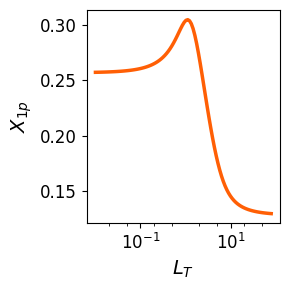

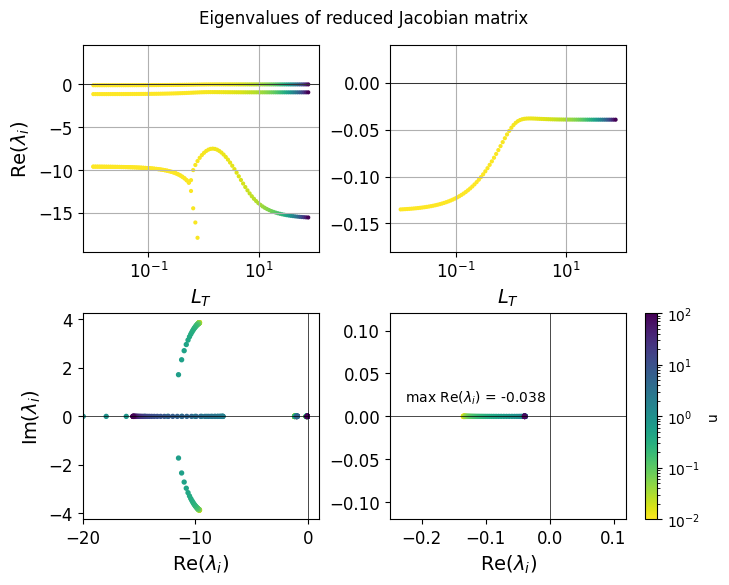

In [5]:
## X1p steady state response curve:
fig, ax = plt.subplots(figsize=(3,3))
plt.plot((LT_array), X1p_output_array,color=rgb_orange_norm,  linestyle='-', linewidth=2.5)
plt.xlabel('$L_T$', fontsize=14)
plt.ylabel('$X_{1p}$', fontsize=14)
ax.tick_params(axis="both", labelsize=12)
plt.xscale('log')
ax.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=[2.0, 5.0], numticks=10))
ax.xaxis.set_minor_formatter(ticker.NullFormatter())
# plt.legend(fontsize=12)
plt.tight_layout()

plt.show()





## eigenvalue plots:
fig, ax = plt.subplots(2, 2, figsize=(7.5, 6))
U = np.tile(LT_array, no_of_phos_species)

ax[0,0].scatter(U, np.real(evals_output_array), c=U,cmap='viridis_r', s=4)
ax[0,0].set_xscale('log')
ax[0,0].set_ylim([-19.5,4.5])
ax[0,0].grid(True)
ax[0,1].scatter(U, np.real(evals_output_array), c=U,cmap='viridis_r', s=4)
ax[0,1].set_xscale('log')
ax[0,1].set_ylim([-0.18,0.04])
ax[0,1].grid(True)
ax[0,0].axhline(0, color='k', lw=0.5)
ax[0,1].axhline(0, color='k', lw=0.5)
ax[0,0].axvline(0, color='k', lw=0.5)
ax[0,1].axvline(0, color='k', lw=0.5)
ax[0,0].set_xlabel('$L_T$', fontsize=14)
ax[0,0].set_ylabel(r'Re($\lambda_i$)', fontsize=14)
ax[0,1].set_xlabel('$L_T$', fontsize=14)
ax[0,0].tick_params(axis="both", labelsize=12)
ax[0,1].tick_params(axis="both", labelsize=12)

ev = evals_output_array.ravel()
sc = ax[1,0].scatter(ev.real, ev.imag, c=U, cmap='viridis_r', s=8, norm=LogNorm())
ax[1,0].axvline(0, color='k', lw=0.5)      # stability boundary
ax[1,0].axhline(0, color='k', lw=0.5)
ax[1,0].set_xlabel(r'Re($\lambda_i$)', fontsize=14)
ax[1,0].set_xlim([-20,1])
ax[1,0].set_ylabel(r'Im($\lambda_i$)', fontsize=14)

sc = ax[1,1].scatter(ev.real, ev.imag, c=U, cmap='viridis_r', s=8, norm=LogNorm(vmin=1e-2, vmax=1e2))
ax[1,1].axvline(0, color='k', lw=0.5)      # stability boundary
ax[1,1].axhline(0, color='k', lw=0.5)
ax[1,1].set_xlabel(r'Re($\lambda_i$)', fontsize=14)
ax[1,1].set_xlim([-0.25,0.12])
ax[1,1].set_ylim([-0.12,0.12])
ax[1,0].tick_params(axis="both", labelsize=12)
ax[1,1].tick_params(axis="both", labelsize=12)
cax = ax[1,1].inset_axes([1.08, 0, 0.05, 1])
cbar = fig.colorbar(sc, cax=cax, label='u')
fig.subplots_adjust(right=0.85, wspace=0.3, hspace=0.3)

max_re = np.max(ev.real)
ax[1,1].annotate(rf'max Re($\lambda_i$) = {max_re:.3g}', xy=(-0.005, 0),
                 xytext=(0, 10), textcoords='offset points',
                 ha='right', fontsize=10);
plt.suptitle('Eigenvalues of reduced Jacobian matrix', y=0.96)
fig.subplots_adjust(top=0.90)
plt.show()